🤖 Machine Learning &nbsp;·&nbsp; *Bài 19/23*

[« Machine Learning - Preprocessing - Categorical Data](018_ml_categorical_data.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Bootstrap Aggregation (Bagging) »](020_ml_bootstrap_aggregation.ipynb)

# Machine Learning - K-means

> 📖 **Học song song trên W3Schools:** [python_ml_k-means.asp](https://www.w3schools.com/python/python_ml_k-means.asp)
>
> 🎯 **Trong bài này:** K-means · How does it work? · Example Explained

## K-means

**K-means** là phương pháp **học không giám sát** để phân cụm các điểm dữ liệu. Thuật toán chia các điểm thành **K cụm** bằng cách tối thiểu hoá **phương sai** trong mỗi cụm.

Ở bài này, ta dùng **phương pháp khuỷu tay (elbow method)** để ước lượng giá trị K tốt nhất, rồi phân cụm bằng K-means.

## How does it work? — Hoạt động thế nào?

1. Mỗi điểm dữ liệu được gán **ngẫu nhiên** vào một trong K cụm.
2. Tính **tâm (centroid)** của mỗi cụm.
3. Gán lại mỗi điểm vào cụm có **tâm gần nhất**.
4. Lặp lại bước 2-3 cho tới khi các cụm **không thay đổi** nữa.

K-means cần chọn **K** — số cụm muốn chia. Vì không biết trước K, ta dùng **elbow method**: chạy K-means với nhiều giá trị K, vẽ **inertia** (tổng bình phương khoảng cách giữa mỗi điểm và tâm cụm của nó) theo K. Điểm **"khuỷu tay"** — nơi inertia bắt đầu giảm chậm và gần như tuyến tính — là giá trị K tốt.

Bắt đầu bằng cách trực quan hoá dữ liệu:

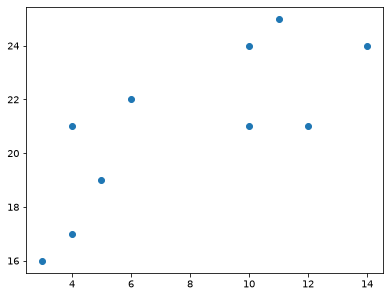

In [1]:
import matplotlib.pyplot as plt

x = [4, 5, 10, 4, 3, 11, 14, 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

plt.scatter(x, y)
plt.show()

Dùng elbow method với K từ 1 đến 10:

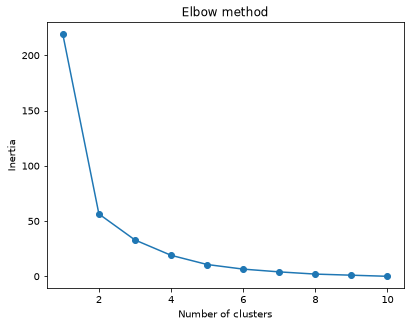

In [2]:
from sklearn.cluster import KMeans

data = list(zip(x, y))
inertias = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=0)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

Đồ thị cho thấy **2** là giá trị K tốt ("khuỷu tay"). Huấn luyện lại K-means và vẽ kết quả:

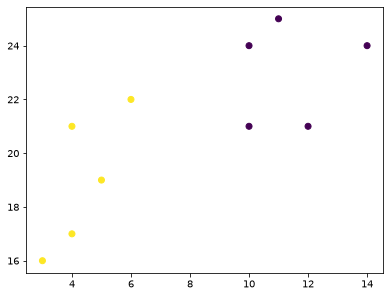

In [3]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

## Example Explained — Giải thích

- `zip()` biến dữ liệu thành các cặp toạ độ.
- Lặp K = 1..10, lưu `inertia_` để vẽ elbow.
- `kmeans.labels_` là nhãn cụm của mỗi điểm — dùng làm màu khi vẽ.

> 💡 Ta đặt `n_init=10` (số lần khởi tạo lại) và `random_state=0` để kết quả ổn định.

---

## 🧠 Ghi nhớ nhanh

> - K-means = học **không giám sát**, chia dữ liệu thành **K** cụm quanh các **tâm**.
> - Chọn K bằng **elbow method**: vẽ `inertia_` theo K, chọn điểm "khuỷu tay".
> - `KMeans(n_clusters=K).fit(data)` → nhãn ở `.labels_`, tâm ở `.cluster_centers_`.

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** Phương pháp nào thường dùng để chọn số cụm K trong K-means?

- **A.** Cross validation
- **B.** Elbow method
- **C.** Grid search
- **D.** One hot encoding

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: B** — Elbow method

</details>

---

[« Machine Learning - Preprocessing - Categorical Data](018_ml_categorical_data.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Bootstrap Aggregation (Bagging) »](020_ml_bootstrap_aggregation.ipynb)